# 01 — Data Audit

## Purpose

This notebook validates the structure and quality of the Home Credit application data before exploratory analysis, feature engineering, and modeling.

The audit answers five questions:

1. Can the required files be loaded successfully?
2. Is each row a unique loan application?
3. Is the target variable correctly defined and materially imbalanced?
4. Which columns have missing, invalid, or unusual values?
5. What cleaning decisions should be carried forward into the data-preparation stage?

> **Scope:** This notebook focuses on data quality. Customer segmentation and business-risk analysis belong in `02_business_eda.ipynb`.

## 1. Setup and File Validation

This section imports the required libraries, locates the project directory, and confirms that the core raw files are available.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Works when the notebook is run from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

required_files = [
    "application_train.csv",
    "application_test.csv",
    "HomeCredit_columns_description.csv",
]

file_check = pd.DataFrame({
    "file": required_files,
    "exists": [(RAW_DATA_DIR / file_name).exists() for file_name in required_files],
})

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
file_check

Project root: /Users/hxxy/Desktop/找工/credit-risk-decisioning
Raw data directory: /Users/hxxy/Desktop/找工/credit-risk-decisioning/data/raw


,file,exists
0,application_train.csv,True
1,application_test.csv,True
2,HomeCredit_columns_description.csv,True


### Interpretation

All required files should return `True`. If a file is missing, stop here and place it in `data/raw/` before continuing.

## 2. Load the Training Data

`application_train.csv` contains one row per application and includes `TARGET`, the outcome used for risk analysis and modeling.

In [2]:
train_path = RAW_DATA_DIR / "application_train.csv"
train = pd.read_csv(train_path)

print("Training data loaded successfully.")
print(f"Rows: {train.shape[0]:,}")
print(f"Columns: {train.shape[1]:,}")
train.head()

Training data loaded successfully.
Rows: 307,511
Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,...,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,...,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,"135,000.00","312,682.50","29,686.50","297,000.00",Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,-19005,-3039,"-9,833.00",-2437,NaN,1,1,0,1,0,0,Laborers,2.00,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00,0.00,-617.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,"121,500.00","513,000.00","21,865.50","513,000.00",Unaccompanied,Working,Secondary / se

### Expected result

The Home Credit training table should contain approximately **307,511 applications** and **122 columns**.

## 3. Schema and Data Types

This section checks the distribution of numeric and categorical fields and provides a compact schema summary.

In [3]:
dtype_summary = (
    train.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("data_type")
    .to_frame("number_of_columns")
)

dtype_summary

,number_of_columns
data_type,
float64,65
int64,41
str,16


In [4]:
categorical_columns = train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns = train.select_dtypes(include="number").columns.tolist()

schema_summary = pd.Series({
    "total_columns": train.shape[1],
    "numeric_columns": len(numeric_columns),
    "categorical_columns": len(categorical_columns),
})

schema_summary

total_columns          122
numeric_columns        106
categorical_columns     16
dtype: int64

### Interpretation

The application table contains a mix of numeric and categorical variables. Categorical fields will require encoding, while numeric fields will require missing-value and anomaly treatment before modeling.

## 4. Record-Level Integrity

The application identifier `SK_ID_CURR` should be unique, and the table should not contain exact duplicate rows.

In [5]:
integrity_summary = pd.Series({
    "total_rows": len(train),
    "duplicate_rows": train.duplicated().sum(),
    "unique_application_ids": train["SK_ID_CURR"].nunique(),
    "duplicate_application_ids": train["SK_ID_CURR"].duplicated().sum(),
})

integrity_summary

total_rows                   307511
duplicate_rows                    0
unique_application_ids       307511
duplicate_application_ids         0
dtype: int64

### Interpretation

A clean result should show:

- no duplicate rows;
- no duplicate `SK_ID_CURR` values;
- the number of unique application IDs equal to the total row count.

This confirms that the main application table is at the **one-row-per-application** grain.

## 5. Target Validation

`TARGET` is the binary outcome:

- `0`: no repayment difficulty;
- `1`: repayment difficulty.

The audit checks class counts and class proportions.

In [6]:
target_summary = (
    train["TARGET"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

target_summary["percentage"] = (
    target_summary["count"] / len(train) * 100
)

target_summary

,count,percentage
TARGET,,
0,282686,91.93
1,24825,8.07


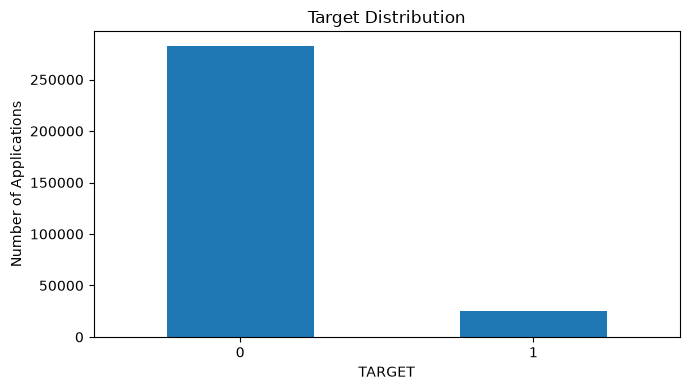

In [7]:
ax = target_summary["count"].plot(kind="bar", figsize=(7, 4))
ax.set_title("Target Distribution")
ax.set_xlabel("TARGET")
ax.set_ylabel("Number of Applications")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The positive class represents roughly 8% of applications, so the dataset is materially imbalanced. Future model evaluation should emphasize metrics such as ROC-AUC, PR-AUC, recall, precision, KS, and calibration rather than accuracy alone.

## 6. Missing-Value Audit

This section ranks columns by missingness and groups them into practical severity bands.

In [8]:
missing_summary = train.isna().sum().to_frame("missing_count")
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(train) * 100
)
missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False,
)

missing_summary.head(20)

,missing_count,missing_percentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35


In [9]:
missing_bins = pd.cut(
    missing_summary["missing_percentage"],
    bins=[-0.01, 0, 10, 30, 50, 100],
    labels=["0%", "0–10%", "10–30%", "30–50%", "50%+"],
)

missing_distribution = (
    missing_bins
    .value_counts()
    .sort_index()
    .rename("number_of_columns")
    .to_frame()
)

missing_distribution

,number_of_columns
missing_percentage,
0%,55
0–10%,10
10–30%,7
30–50%,9
50%+,41


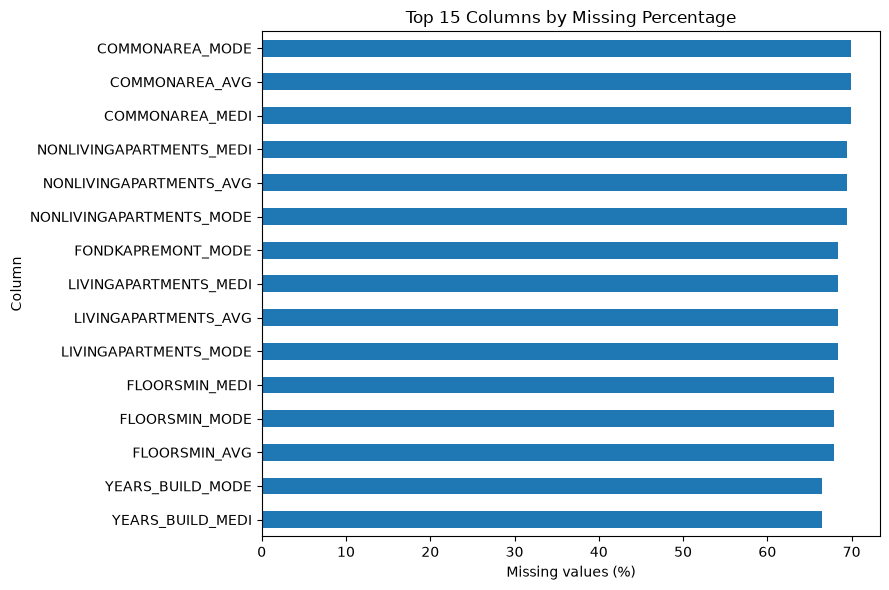

In [10]:
top_missing = missing_summary.head(15).sort_values("missing_percentage")

ax = top_missing["missing_percentage"].plot(
    kind="barh",
    figsize=(9, 6),
)
ax.set_title("Top 15 Columns by Missing Percentage")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

### Interpretation

Many of the highest-missing fields describe housing or building characteristics. Missingness may reflect unavailable customer information rather than random data loss. These variables should not be dropped automatically; missing indicators may retain useful information.

## 7. Categorical-Value Audit

This section checks category cardinality, missingness, and known placeholder values.

In [11]:
categorical_summary = pd.DataFrame({
    "unique_categories": train[categorical_columns].nunique(dropna=True),
    "missing_count": train[categorical_columns].isna().sum(),
    "missing_percentage": train[categorical_columns].isna().mean() * 100,
}).sort_values("unique_categories", ascending=False)

categorical_summary

,unique_categories,missing_count,missing_percentage
ORGANIZATION_TYPE,58,0,0.00
OCCUPATION_TYPE,18,96391,31.35
NAME_INCOME_TYPE,8,0,0.00
NAME_TYPE_SUITE,7,1292,0.42
WEEKDAY_APPR_PROCESS_START,7,0,0.00
WALLSMATERIAL_MODE,7,156341,50.84
NAME_FAMILY_STATUS,6,0,0.00
NAME_HOUSING_TYPE,6,0,0.00
NAME_EDUCATION_TYPE,5,0,0.00
FONDKAPREMONT_MODE,4,210295,68.39


In [12]:
placeholder_checks = {
    "CODE_GENDER": ["XNA"],
    "NAME_FAMILY_STATUS": ["Unknown"],
    "ORGANIZATION_TYPE": ["XNA"],
}

placeholder_records = []

for column, values in placeholder_checks.items():
    for value in values:
        count = (train[column] == value).sum()
        placeholder_records.append({
            "column": column,
            "placeholder_value": value,
            "count": count,
            "percentage": count / len(train) * 100,
        })

placeholder_summary = pd.DataFrame(placeholder_records)
placeholder_summary

,column,placeholder_value,count,percentage
0,CODE_GENDER,XNA,4,0.00
1,NAME_FAMILY_STATUS,Unknown,2,0.00
2,ORGANIZATION_TYPE,XNA,55374,18.01


### Interpretation

Known special values require different treatment:

- `CODE_GENDER = XNA` and `NAME_FAMILY_STATUS = Unknown` are rare unknown values and can be converted to missing.
- `ORGANIZATION_TYPE = XNA` is common and may encode unemployment, retirement, or unavailable employer information. It should be retained as a meaningful category or accompanied by an indicator.
- Normal categories such as `Unaccompanied` or `Other` should not be recoded as missing.

## 8. Numeric Anomaly Audit

The audit checks for infinite values, constant columns, known sentinel values, and extreme financial observations.

In [13]:
constant_columns = train.nunique(dropna=False)
constant_columns = constant_columns[constant_columns <= 1]

infinite_counts = np.isinf(train[numeric_columns]).sum()
infinite_columns = infinite_counts[infinite_counts > 0]

numeric_quality_summary = pd.Series({
    "constant_columns": len(constant_columns),
    "columns_with_infinite_values": len(infinite_columns),
})

numeric_quality_summary

constant_columns                0
columns_with_infinite_values    0
dtype: int64

In [14]:
employment_anomaly_count = (train["DAYS_EMPLOYED"] == 365243).sum()

pd.Series({
    "DAYS_EMPLOYED_365243_count": employment_anomaly_count,
    "DAYS_EMPLOYED_365243_percentage": employment_anomaly_count / len(train) * 100,
})

DAYS_EMPLOYED_365243_count        55,374.00
DAYS_EMPLOYED_365243_percentage       18.01
dtype: float64

In [15]:
financial_columns = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

train[financial_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,"307,511.00","168,797.92","237,123.15","25,650.00","112,500.00","147,150.00","202,500.00","117,000,000.00"
AMT_CREDIT,"307,511.00","599,026.00","402,490.78","45,000.00","270,000.00","513,531.00","808,650.00","4,050,000.00"
AMT_ANNUITY,"307,499.00","27,108.57","14,493.74","1,615.50","16,524.00","24,903.00","34,596.00","258,025.50"
AMT_GOODS_PRICE,"307,233.00","538,396.21","369,446.46","40,500.00","238,500.00","450,000.00","679,500.00","4,050,000.00"


In [16]:
income_quantiles = train["AMT_INCOME_TOTAL"].quantile(
    [0.95, 0.99, 0.999, 0.9999, 1.0]
)

income_quantiles

0.95       337,500.00
0.99       472,500.00
1.00       900,000.00
1.00     2,250,000.00
1.00   117,000,000.00
Name: AMT_INCOME_TOTAL, dtype: float64

### Interpretation

Key findings to carry into data preparation:

- `DAYS_EMPLOYED = 365243` is an artificial sentinel, not a real employment duration. Replace it with missing and create an anomaly flag.
- `AMT_INCOME_TOTAL` contains extreme right-tail values, including a very large maximum. Retain the original value for traceability, but consider log transformation or winsorization for linear models and visualizations.
- Small amounts of missingness in `AMT_ANNUITY` and `AMT_GOODS_PRICE` require imputation.
- Infinite values and constant columns, if absent, do not require treatment.

## 9. Audit Conclusions and Cleaning Plan

### Key findings

1. The training table is at the correct one-row-per-application grain and contains no duplicate application IDs.
2. `TARGET` is strongly imbalanced, with repayment difficulty representing only a small share of applications.
3. Several housing-related variables have missing rates above 50%.
4. Categorical placeholders require field-specific treatment rather than blanket replacement.
5. `DAYS_EMPLOYED = 365243` is a confirmed sentinel value.
6. Income contains extreme outliers and is strongly right-skewed.

### Cleaning decisions for `03_data_preparation.ipynb`

- Convert `DAYS_EMPLOYED = 365243` to missing and create `DAYS_EMPLOYED_ANOMALY`.
- Convert rare unknown categories such as `CODE_GENDER = XNA` to missing.
- Preserve `ORGANIZATION_TYPE = XNA` as a meaningful category or indicator.
- Add missing-value indicators for strategically important high-missing variables.
- Impute numeric variables using training-data statistics only.
- Impute categorical variables with an explicit `Missing` category.
- Consider log transformation or winsorization for highly skewed monetary variables.
- Keep all transformations inside a reproducible preprocessing pipeline to prevent data leakage.

### Next notebook

Proceed to `02_business_eda.ipynb` to analyze repayment-difficulty rates across customer segments, affordability measures, age groups, and external credit scores.